## FINAL PROJECT: R&D Potential of World Economies
### DATA SCIENCE 201 - Spring 2026
### Name: Raul Miranda
### May 11, 2026

## Short Introduction

### Factors affecting R&D spending

The goals of this project are both to predict R&D investment of world regions, understand the main factors, and to compare the accuracy of regression methods based on decision trees and support vector machines.

During project 2 we started to examine the features that characterize R&D investment, using linear (multilinear) regression algorithms. In that project we identified log(GDP/capita) as the dominant feature, followed by structural strengths: specifically investment in health and education and thirly, by regional factors, specifically continent. We learned that public uncertainty (according to the index maintained by the International Monetary Fund) is not a major factor affecting R&D short-term investment.

For this final project, I will address an inconsistency observed in project 2. The ranking of nations by GDP/capita agrees only partially with their ranking according to R&D investment and global R&D impact. Other factors must be considered to fully encapsulate the features that characterize R&D investment and global impact. Among the factors that also seem important are: human infrastrure for R&D, such as the number of active researchers in each country (or the correlated number of publications per year), and government policy factors, such as reliability (continuity of funding) and legal protection of IP.

Thus we will examine the importance of human infrastructure (active R&D researchers) and government effectiveness in providing a legal and financial environment conducive to R&D, relative to the other economic and structural factors mentioned above. Both features are quantified by World Bank indicators: researchers_per_million, and government_effectiveness.

### Relevance to Maryland

R&D in all fields constitutes a major economic and social activity in Maryland. According to NSF's Science and Engineering Indicators, Maryland's S&E Workforce in 2017, was 201,310, growing at 7.8% in the 2013-2017 period (cited by SSTI.org, https://ssti.org/blog/useful-stats-science-and-engineering-workforce-state-2003-2017), faster than other sectors. The Sentinel comments in "Science Matters to Maryland" are relevant (https://www.thesentinel.com/communities/science-matters-to-maryland/article_c11ac4dc-ef29-11ef-8753-8b157018ba6a.html), showing MD as the recipient of several billion dollars annually from federal funding. With over 350 federal and academic research centers in all aspects of physical, biological and social science, medicine, and humanities, MD ranks among the top 5 or 7 (depending on sources) research hubs in the US. Some sources rank MD as 1 or 2 in concentration of PhD/MD level researchers in the nation, together with or after Washington DC. (https://msa.maryland.gov/megafile/msa/speccol/sc5300/sc5339/000113/003000/003376/unrestricted/20070141e.pdf).  As the Sentinel and many other sources have declared, lapses in research funding affect not only the states finances dramatically but also the national competitiveness in various aspect: economic, scientific, industrial, social, and military. It is important to numerically show the relevance of factors that influence R&D funding in general, affecting also Maryland.

### Comparison of Tree-Based Regression Methods, and Support Vector Machine Methods

A key goal for this project is to learn and compare tree-based and SVM methods for regression, specifically: Decision Tree, Random Forest (Bagging), Gradient Boosting, SVM and SVM-Ada. We will assess how effective they are in obtaining high accuracy predictions (measured by R2-score and Mean Squared Error) while avoiding overfitting.
These methods are readily available in the SKlearn package.  We will follow closely the demo done in class.

#### A short overview of the methods

Decision Tree regressor: useful as a base model but may be prone to overfitting, something we will assess in this project. The tree partitions the features into separate regions (leaves) and predicts the mean target value for the test samples falling into those regions. It follows a logical path maximizing the information density at each node (decision points) for each level. One tries to avoid overfitting (or too many separate regions) by minimizing the number of levels while keeping high prediction accuracy.

Random Forest regressor: is a useful bagging technique that randomly subdivides the training set into subsets and trains them in parallel using different subsets of the features. It then aggregates the results into a more generalizable result than a single tree because the random subsetting of features at each node helps to reduce the variance of the aggregated model.

Gradient Boosting regressor: this is a sequential training method of decision trees, that aims to reduce residuals at each training step following the steepest descent of the loss function. The aggregate is the weighted sum of all the predictions from the sequence of trees. In principle, it is more accurate than a single decision tree. 

Support Vector Machines regressor: this method works by separating regions of multidimensional space containing groups of training data, with maximum distance between them. That is, by generating an optimal hyperplane of features that distinguishes the training subsets with a minimum aggregated error. Feature scaling is required. 

SVM with Bagging regressor: bagging or parallel training of several SVM models following by aggregation of all the predictions can lead to a more accurate result than a single SVM.

SVM with Boosting regressor: AdaBoost SVM is a sequential training of SVM models that are gradually improved. The aggregate SVM model is in principle more accurate than individual SVMs. 

## Databases

In Project 2 we did construct the database by merging selected World Bank Indicators and the World Uncertainty Index. We will only add two indicators from the World Bank: govt_effectiveness and researchers_per_million, and evaluate how critical those are to the model.

The data is restricted to 52 countries and to the 1995-2024 period, since many countries did not report economic data prior to that period.

**World Uncertainty Index** http://worlduncertaintyindex.com/data/, downloaded to project folder as WUI_data.xlsx. The second tab: T2, filtered for the 1995-2024 period was downloaded to project folder as wuncertindex.csv.

The World Uncertainty Index is a measure that tracks uncertainty across the globe by sentiment analysis of country reports of the Economist Intelligence Unit of the International Monetary Fund. The index is available for 143 countries and published quarterly since the 1950s. Score: (positive words-negative words)/total words x 1000.

**World Bank - Development Indicators** https://databank.worldbank.org/source/world-development-indicators - selected: time period: 1995-2024, countries shown below, and these 6 indicator codes:

"NY.GDP.PCAP.CD":    "gdp_per_capita_usd" - GDP/capita
"SP.DYN.LE00.IN":    "life_expectancy"    - life expectancy
"SE.XPD.TOTL.GD.ZS": "education_spend_pct_gdp" - education, %GDP
"SH.XPD.CHEX.GD.ZS": "health_spend_pct_gdp" - health, %GDP
"GB.XPD.RSDV.GD.ZS": "rd_spend_pct_gdp"   - R&D, %GDP

Added to Final Project:
"SP.POP.SCIE.RD.P6":  "researchers_per_million"  - measures R&D human capital

**Worlwide Governance Indicators** https://www.worldbank.org/en/publication/worldwide-governance-indicators; time period: 1996-2024. Countries shown below.
"GE.EST":             "govt_effectiveness"       - score measuring  quality of public services, the civil
service, policy formulation and implementation, and the credibility of a government’s decisions. range= -2.5:2.5

Countries are uniquely identified by their ISO-3 code.

Regions: Europe, North America, Latin America, Asia-Pacific, Middle-East, Africa

Income status: High, Upper-Middle, Lower-Middle, Low

The selection was downloaded to the project folder as: worldbank.csv.
Both worldbank.csv and wuncertindex.csv were merged by iso-3 code and year, to yield wuiwbi.csv, used as input for this project.

### Data limitations. Population of interest. Bias concerns.

Finding a good intersection of data (WUI and WBI) without too many NaN forced us to restrict the years to **1995-2024**, and the countries to **52 nations**. That eliminated the Low income status countries. Thus the conclusions from this analysis is biased by the lack of data from certain nations.

Country-ISO3 selected: "USA", "GBR", "FRA", "DEU", "ITA", "ESP", "NLD", "BEL", "SWE", "NOR", "DNK", "FIN", "AUT", "CHE", "PRT", "IRL", "CAN", "AUS", "NZL", "JPN", "KOR", "ISR", "SAU", "ARE", "QAT", "KWT", "CHN", "BRA", "MEX", "ARG", "ZAF", "TUR", "POL", "HUN", "CZE", "ROU", "MYS", "THA", "COL", "PER", "IND", "IDN", "PAK", "EGY", "MAR", "NGA", "KEN", "UKR", "RUS", "IRQ", "IRN", "GRC"

### Load the necessary libraries.

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from scipy import stats

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import plot_tree

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.ensemble import BaggingRegressor
from sklearn.ensemble import AdaBoostRegressor

# Set a style for plots
sns.set_style("whitegrid")

### Load the dataset and clean it.


In [20]:
# load dataset

try:
    HERE = Path(__file__).resolve().parent   # point to my project folder
except NameError:
    HERE = Path.cwd()                        # if _file_ is undefined, change cwd to my project folder

wuiwbi = pd.read_csv(HERE / "wuiwbi.csv")    # read wuiwbi
print(f"WUIWBI shape (rows, columns): {wuiwbi.shape}")
print("\nColumn/variable names:")
for c in wuiwbi.columns:
    print(" ", c)
print("""\nCategorical variables: country_iso3, region, income_group
Numerical variables: the other variables in units: U$S, year or dimensionless.
    wui:  world uncertainty index
    wui_volatility: a three-quarter weighted average of wui
    govt_effectiveness: see definition above.
""")

WUIWBI shape (rows, columns): (1560, 13)

Column/variable names:
  country_iso3
  year
  region
  income_group
  gdp_per_capita_usd
  life_expectancy
  health_spend_pct_gdp
  education_spend_pct_gdp
  rd_spend_pct_gdp
  researchers_per_million
  govt_effectiveness
  wui
  wui_volatility

Categorical variables: country_iso3, region, income_group
Numerical variables: the other variables in units: U$S, year or dimensionless.
    wui:  world uncertainty index
    wui_volatility: a three-quarter weighted average of wui
    govt_effectiveness: see definition above.



In [21]:
# cleaning

print(wuiwbi.head())
print(wuiwbi.info())
print(wuiwbi.isna().sum())  # how many NaNs in each column
wuiwbi = wuiwbi.fillna(wuiwbi.median(numeric_only=True)) # impute NaNs
print(wuiwbi.isna().sum()) # check if all the  NaNs were removed

# Define new variables to be used in the statistical analysis section

# Log GDP/capita

wuiwbi['log_gdp'] = np.log1p(wuiwbi['gdp_per_capita_usd'])


  country_iso3  year       region income_group  gdp_per_capita_usd  \
0          ARE  1995  Middle East         High        27003.200681   
1          ARE  1996  Middle East         High        28323.165087   
2          ARE  1997  Middle East         High        27982.795704   
3          ARE  1998  Middle East         High        24889.426919   
4          ARE  1999  Middle East         High        25855.860505   

   life_expectancy  health_spend_pct_gdp  education_spend_pct_gdp  \
0           71.392              2.395045                   3.8602   
1           71.820              2.395045                   3.8602   
2           72.559              2.395045                   3.8602   
3           73.660              2.395045                   3.8602   
4           74.982              2.395045                   3.8602   

   rd_spend_pct_gdp  researchers_per_million  govt_effectiveness       wui  \
0           0.47252               2168.42732            0.776640  0.050293   
1       

BASIC STATISTICS
       researchers_per_million  govt_effectiveness
count                 1560.000            1560.000
mean                  2383.255               0.630
std                   2114.454               0.939
min                     22.120              -2.089
25%                    559.540              -0.175
50%                   1770.754               0.623
75%                   3761.099               1.537
max                   9471.825               2.347

Pearson r: 0.744  (p = 0.0000,  n = 1560)


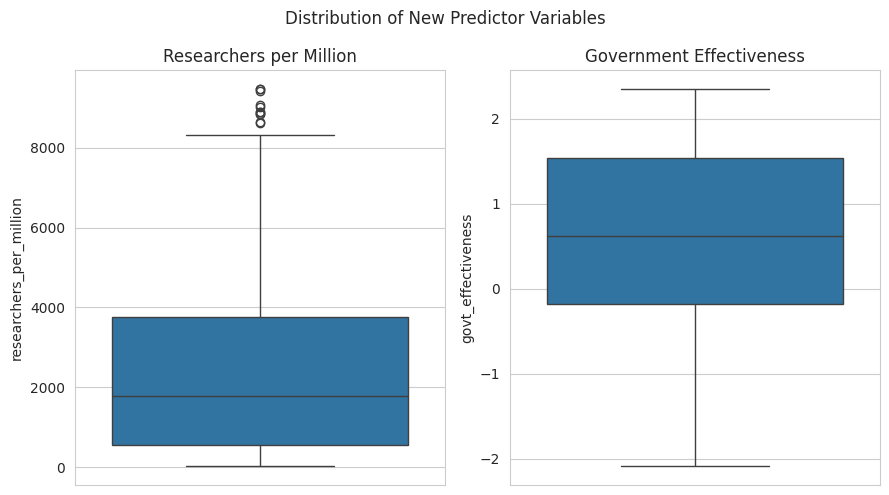

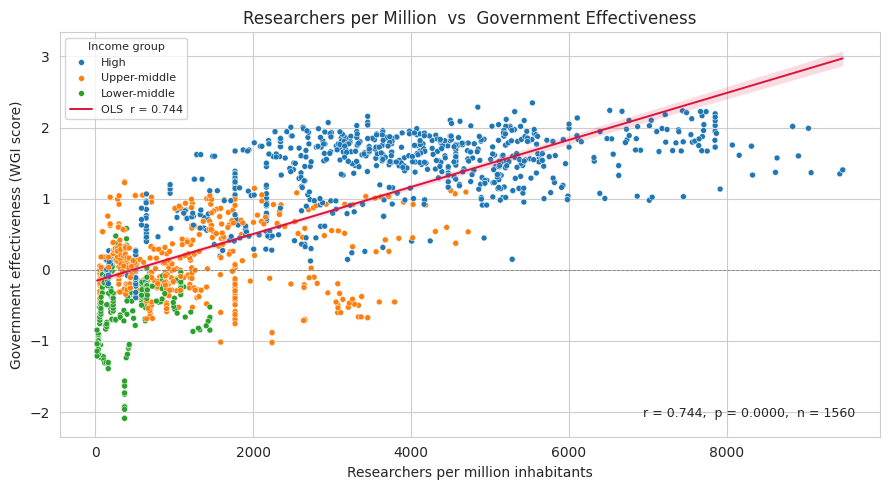

In [29]:
# basic stats for researchers per million and for govt effectiveness

cols = ["researchers_per_million", "govt_effectiveness", "income_group"]
print("=" * 55)
print("BASIC STATISTICS")
print("=" * 55)
print(wuiwbi[cols].describe().round(3).to_string())
clean = wuiwbi[cols].dropna()
r, p  = stats.pearsonr(clean["researchers_per_million"], clean["govt_effectiveness"])
print(f"\nPearson r: {r:.3f}  (p = {p:.4f},  n = {len(clean)})")

# ── Box plots for researchers_per_million and govt_effectiveness ──

fig, axes = plt.subplots(1, 2, figsize=(9, 5))

sns.boxplot(y=wuiwbi["researchers_per_million"], ax=axes[0])
axes[0].set_title("Researchers per Million")

sns.boxplot(y=wuiwbi["govt_effectiveness"], ax=axes[1])
axes[1].set_title("Government Effectiveness")

plt.suptitle("Distribution of New Predictor Variables", fontsize=12)
plt.tight_layout()
plt.show()

# nice plot of the 2 variables

fig, ax = plt.subplots(figsize=(9, 5))

sns.scatterplot(data=clean, x="researchers_per_million", y="govt_effectiveness",
                hue="income_group", alpha=1, s=18, ax=ax)

sns.regplot(data=clean, x="researchers_per_million", y="govt_effectiveness",
            scatter=False, line_kws=dict(color="crimson", linewidth=1.4),
            label=f"OLS  r = {r:.3f}", ax=ax)

ax.set_title("Researchers per Million  vs  Government Effectiveness")
ax.set_xlabel("Researchers per million inhabitants")
ax.set_ylabel("Government effectiveness (WGI score)")
ax.axhline(0, color="grey", linewidth=0.6, linestyle="--")
ax.annotate(f"r = {r:.3f},  p = {p:.4f},  n = {len(clean)}",
            xy=(0.97, 0.05), xycoords="axes fraction",
            ha="right", fontsize=9)
ax.legend(title="Income group", fontsize=8, title_fontsize=8)

plt.tight_layout()
plt.show()

### Identify the variables for the prediction of rd_spend_pct_gdp and split data into train/test subsets

In [30]:
# Convert categorical variables (region, income group) to dummies; don't drop reference levels yet

wuiwbi = pd.get_dummies(wuiwbi, columns=['region', 'income_group'], drop_first=False)  #make 6+3 dummies

# identify the categorical variables 
cat_vars = [col for col in wuiwbi.columns if 'region_' in col or 'income_group_' in col]

# basic features without categorical dummies
features_basic = ['log_gdp', 'wui', 'wui_volatility' ,'life_expectancy', 'education_spend_pct_gdp', 'health_spend_pct_gdp', "govt_effectiveness", "researchers_per_million"] 

# all features including categorical dummies
features_cat = features_basic + cat_vars

X = wuiwbi[features_cat]
y = wuiwbi['rd_spend_pct_gdp']

In [31]:

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

print(f"Dataset features: {list(X.columns)}")
print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Dataset features: ['log_gdp', 'wui', 'wui_volatility', 'life_expectancy', 'education_spend_pct_gdp', 'health_spend_pct_gdp', 'govt_effectiveness', 'researchers_per_million', 'region_Africa', 'region_Asia-Pacific', 'region_Europe', 'region_Latin America', 'region_Middle East', 'region_North America', 'income_group_High', 'income_group_Lower-middle', 'income_group_Upper-middle']

Training set size: 1248 samples
Testing set size: 312 samples


## Decision Tree Regressor
### Test Overfitting

Define the dt regressor, train it with training subset, and predict rd_spend_pct_gdp with the test subset. To test for overfitting, we will predict with two models, with max_depth of 8 and 16. In principle the stronger model (max_depth of 16 may overfit.) 

In [33]:
# dt regressor
# set max_depth to a low number of levels to prevent extreme overfitting
dt_model_8 = DecisionTreeRegressor(max_depth=8, random_state=1)   #  try with 8 levels
dt_model_8.fit(X_train, y_train)

# make predictions
dt_predictions_8 = dt_model_8.predict(X_test)

In [34]:
# more complex dt regressor
# set max_depth to 16 to see whether it overfits
dt_model_16 = DecisionTreeRegressor(max_depth=16, random_state=1)     # try with 16 levels
dt_model_16.fit(X_train, y_train)

# make predictions
dt_predictions_16 = dt_model_16.predict(X_test)

**Model Metrics for Decision Tree**
Mean Squared Error (MSE) and $R^2$ score.

In [35]:
# metrics with 8 levels
dt_mse = mean_squared_error(y_test, dt_predictions_8)
dt_r2 = r2_score(y_test, dt_predictions_8)

print("--- Decision Tree Regressor Metrics with 8 levels---")
print(f"Mean Squared Error (MSE): {dt_mse:.3f}")
print(f"R-squared (R2) Score: {dt_r2:.3f}")

# keep results
dt_results_8 = {'MSE': dt_mse, 'R2': dt_r2, 'Model': 'Decision Tree_8 levels'}

--- Decision Tree Regressor Metrics with 8 levels---
Mean Squared Error (MSE): 0.114
R-squared (R2) Score: 0.908


In [36]:
# metrics with 16 levels
dt_mse = mean_squared_error(y_test, dt_predictions_16)
dt_r2 = r2_score(y_test, dt_predictions_16)

print("--- Decision Tree Regressor Metrics with 16 levels---")
print(f"Mean Squared Error (MSE): {dt_mse:.3f}")
print(f"R-squared (R2) Score: {dt_r2:.3f}")

# keep esults for comparison
dt_results_16 = {'MSE': dt_mse, 'R2': dt_r2, 'Model': 'Decision Tree_16 levels'}

--- Decision Tree Regressor Metrics with 16 levels---
Mean Squared Error (MSE): 0.095
R-squared (R2) Score: 0.923


**Is there overfitting?**

Had there been overfitting, the R2 score for the more complex model (16-level tree) would have been smaller than that of the weaker model (8-level tree). Since the R2 score for the 16-level tree is slightly higher than that for the 8-level tree, there is no sign of overfitting. Since both models are highly accurate with R2>0.9, it is preferable to use the 8-level tree, which is simpler and faster.

**Visualize the tree structure of the 8-level dt**
Using sklearn.tree.plot_tree we limit level to 3 for a clear diagram.

--- Decision Tree Structure Visual ---


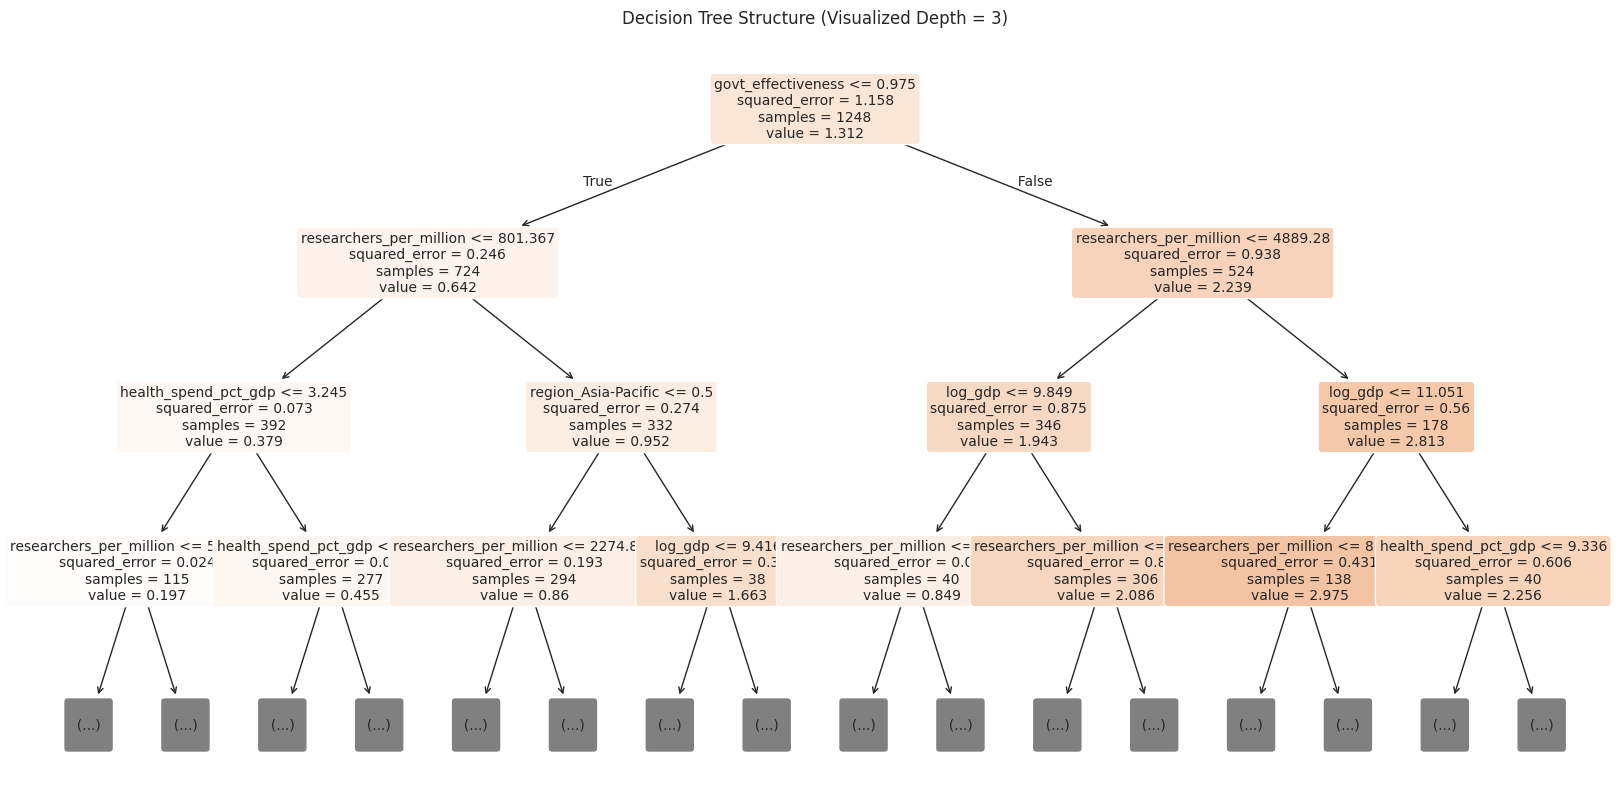

In [37]:
print("--- Decision Tree Structure Visual ---")

plt.figure(figsize=(20, 10))
plot_tree(dt_model_8,
    max_depth=3,  # limit depth for a clear image
    feature_names=X_train.columns.tolist(), filled=True, rounded=True, fontsize=10)
plt.title(f"Decision Tree Structure (Visualized Depth = 3)")
plt.show()

**Interpret:**

**decision nodes:** Each box represents a decision node or a leaf node.

**split criterion:** Threshold used to split the data (e.g., gov_effectiveness<=0.975.)

**squared error:** The Mean Squared Error for the samples in that node. Decreases down the tree, indicating purer nodes.

**samples:** The number of training samples falling in that node.

**value:** The average target value (rd_spend_pct_gdp) for training samples in that node.

**Visualize predictions against actual values for the 8-level dt**

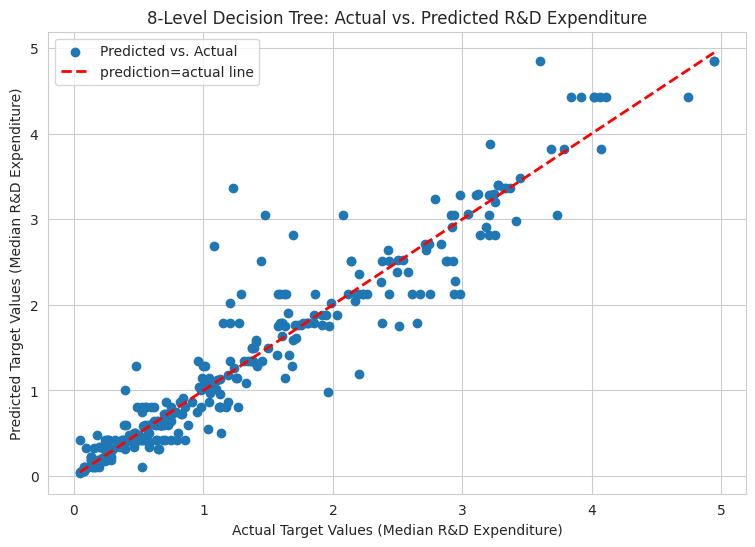

In [38]:
plt.figure(figsize=(9, 6))
plt.scatter(y_test, dt_predictions_8, alpha=1, label='Predicted vs. Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='prediction=actual line')
plt.title('8-Level Decision Tree: Actual vs. Predicted R&D Expenditure')
plt.xlabel('Actual Target Values (Median R&D Expenditure)')
plt.ylabel('Predicted Target Values (Median R&D Expenditure)')
plt.legend()
plt.show()

## Random Forest Regressor

Define the rf regressor, train it with training subset, and predict rd_spend_pct_gdp with the test subset.

In [39]:
# define the rf regressor model
# n_estimators: number of trees in the forest with a max of 8 levels each
rf_model = RandomForestRegressor(n_estimators=150, max_depth=8, random_state=1, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Make predictions
rf_predictions = rf_model.predict(X_test)

**Model Metrics: Random Forest Regressor**

In [40]:
# rsquare and mse
rf_mse = mean_squared_error(y_test, rf_predictions)
rf_r2 = r2_score(y_test, rf_predictions)

print("--- Random Forest Regressor Metrics ---")
print(f"Mean Squared Error (MSE): {rf_mse:.3f}")
print(f"R-squared (R2) Score: {rf_r2:.3f}")

# keep results
rf_results = {'MSE': rf_mse, 'R2': rf_r2, 'Model': 'Random Forest'}

--- Random Forest Regressor Metrics ---
Mean Squared Error (MSE): 0.080
R-squared (R2) Score: 0.935


**Visualize Random Forest Predictions**

A Random Forest averages the output of many trees. Visualizing the distribution of predictions from each individual tree in the forest shows how much variation across trees.

/home/raulginomiranda/Python/env/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/home/raulginomiranda/Python/env/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/home/raulginomiranda/Python/env/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/home/raulginomiranda/Python/env/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/home/raulginomiranda/Python/env/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without f

--- Random Forest Prediction Distribution ---
Sample True Value (y_test): 0.131
Random Forest Aggregate Prediction: 0.206
Prediction Standard Deviation: 0.097


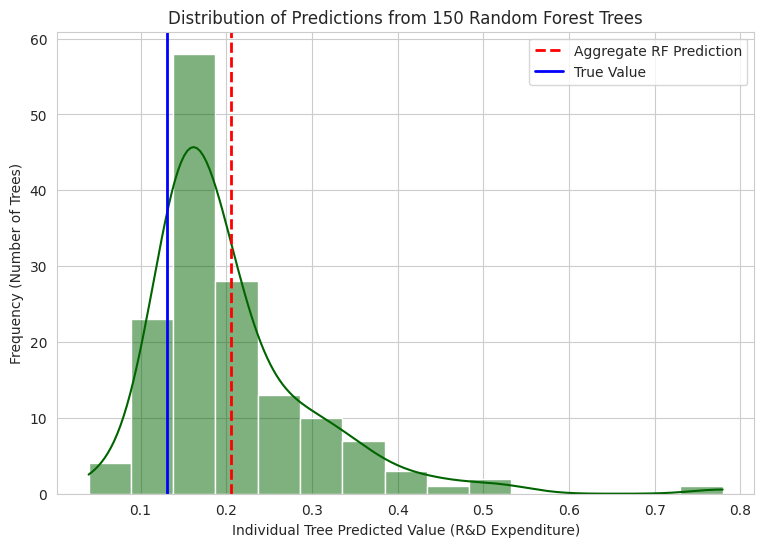

In [41]:
# first test sample to observe
test_sample_index = 20
sample_features = X_test.iloc[test_sample_index]
sample_true_value = y_test.iloc[test_sample_index]

# predictions from every individual tree in the Random Forest
tree_predictions = []
for tree in rf_model.estimators_:
    # Reshape the single sample to match the model's expected input (1, n_features)
    prediction = tree.predict(sample_features.to_frame().T)
    tree_predictions.append(prediction[0])

# convert to series
tree_predictions_series = pd.Series(tree_predictions)

print("--- Random Forest Prediction Distribution ---")
print(f"Sample True Value (y_test): {sample_true_value:.3f}")
print(f"Random Forest Aggregate Prediction: {rf_predictions[test_sample_index]:.3f}")
print(f"Prediction Standard Deviation: {tree_predictions_series.std():.3f}")


# plot the distribution
plt.figure(figsize=(9, 6))
sns.histplot(tree_predictions_series, kde=True, bins=15, color='darkgreen')
plt.axvline(rf_predictions[test_sample_index], color='red', linestyle='--', linewidth=2, label='Aggregate RF Prediction')
plt.axvline(sample_true_value, color='blue', linestyle='-', linewidth=2, label='True Value')
plt.title(f'Distribution of Predictions from {len(rf_model.estimators_)} Random Forest Trees')
plt.xlabel('Individual Tree Predicted Value (R&D Expenditure)')
plt.ylabel('Frequency (Number of Trees)')
plt.legend()
plt.show()

/home/raulginomiranda/Python/env/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/home/raulginomiranda/Python/env/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/home/raulginomiranda/Python/env/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/home/raulginomiranda/Python/env/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/home/raulginomiranda/Python/env/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without f

--- Random Forest Prediction Distribution ---
Sample True Value (y_test): 1.756
Random Forest Aggregate Prediction: 2.103
Prediction Standard Deviation: 0.410


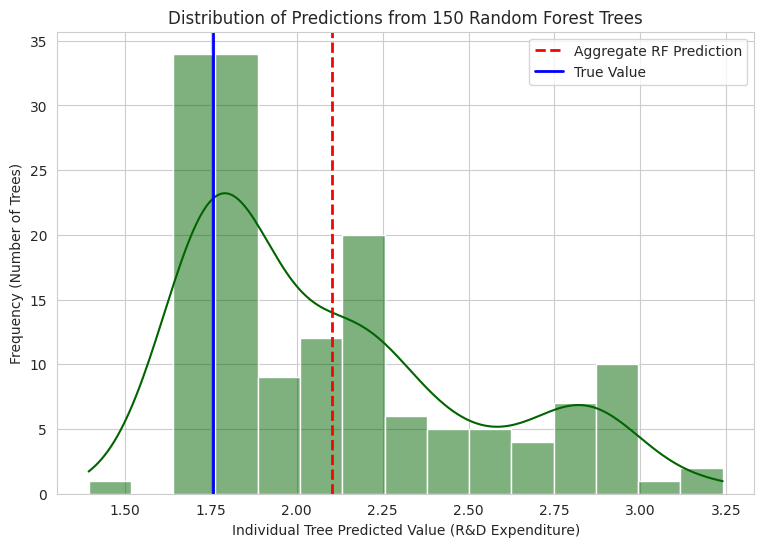

In [42]:
# second test sample to observe
test_sample_index = 100
sample_features = X_test.iloc[test_sample_index]
sample_true_value = y_test.iloc[test_sample_index]

# predictions from every individual tree in the Random Forest
tree_predictions = []
for tree in rf_model.estimators_:
    # Reshape the single sample to match the model's expected input (1, n_features)
    prediction = tree.predict(sample_features.to_frame().T)
    tree_predictions.append(prediction[0])

# convert to series
tree_predictions_series = pd.Series(tree_predictions)

print("--- Random Forest Prediction Distribution ---")
print(f"Sample True Value (y_test): {sample_true_value:.3f}")
print(f"Random Forest Aggregate Prediction: {rf_predictions[test_sample_index]:.3f}")
print(f"Prediction Standard Deviation: {tree_predictions_series.std():.3f}")


# plot the distribution
plt.figure(figsize=(9, 6))
sns.histplot(tree_predictions_series, kde=True, bins=15, color='darkgreen')
plt.axvline(rf_predictions[test_sample_index], color='red', linestyle='--', linewidth=2, label='Aggregate RF Prediction')
plt.axvline(sample_true_value, color='blue', linestyle='-', linewidth=2, label='True Value')
plt.title(f'Distribution of Predictions from {len(rf_model.estimators_)} Random Forest Trees')
plt.xlabel('Individual Tree Predicted Value (R&D Expenditure)')
plt.ylabel('Frequency (Number of Trees)')
plt.legend()
plt.show()

**Interpret:**

**Distribution**: histogram of values or rd_spend_pc_gdp for the 150 individual trees in the Random Forest for a single data point.

**Red Dashed Line:** reported prediction by the Random Forest model—the average of the entire distribution.

**Blue Solid Line:** This is the actual true value from the test set.

**Robustness**: A tight distribution (low standard deviation) indicates agreement among the trees, and a more robust prediction. The closer the red line is to the blue line, the more accurate the prediction is. The standard deviations of .097 and .41 are acceptable.

**Visualize Actual versus Predicted: Random Forest**

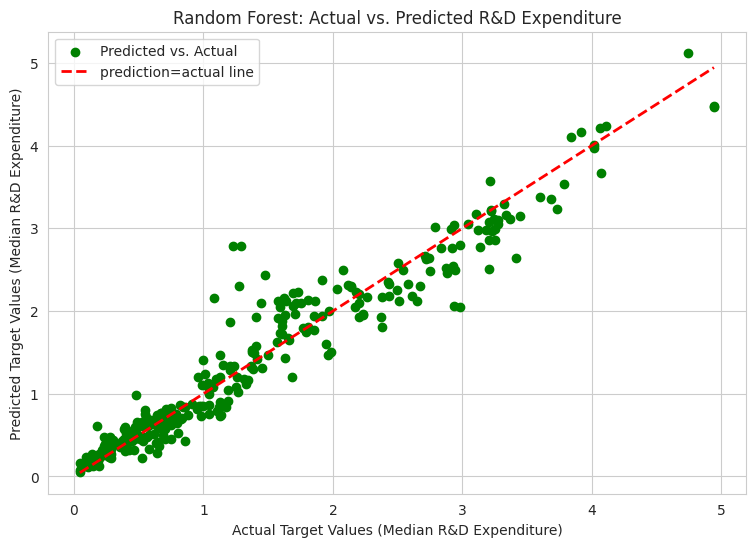

In [43]:
plt.figure(figsize=(9, 6))
plt.scatter(y_test, rf_predictions, alpha=1, color='green', label='Predicted vs. Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='prediction=actual line')
plt.title('Random Forest: Actual vs. Predicted R&D Expenditure')
plt.xlabel('Actual Target Values (Median R&D Expenditure)')
plt.ylabel('Predicted Target Values (Median R&D Expenditure)')
plt.legend()
plt.show()

## Gradient Boosting Regressor
Define the gb regressor, train it with training subset, and predict rd_spend_pct_gdp with the test subset.

In [44]:
# define and train the Gradient Boosting Regressor
# learning_rate controls the contribution of each tree
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=8, random_state=1)
gb_model.fit(X_train, y_train)

# make predictions
gb_predictions = gb_model.predict(X_test)

**Model Metrics for Gradient Boosting Regressor**

In [45]:
# metrics
gb_mse = mean_squared_error(y_test, gb_predictions)
gb_r2 = r2_score(y_test, gb_predictions)

print("--- Gradient Boosting Regressor Metrics ---")
print(f"Mean Squared Error (MSE): {gb_mse:.3f}")
print(f"R-squared (R2) Score: {gb_r2:.3f}")

# keep results
gb_results = {'MSE': gb_mse, 'R2': gb_r2, 'Model': 'Gradient Boosting'}

--- Gradient Boosting Regressor Metrics ---
Mean Squared Error (MSE): 0.056
R-squared (R2) Score: 0.955


**Visualize Actual Versus Predicted Values with Gradient Boosting**

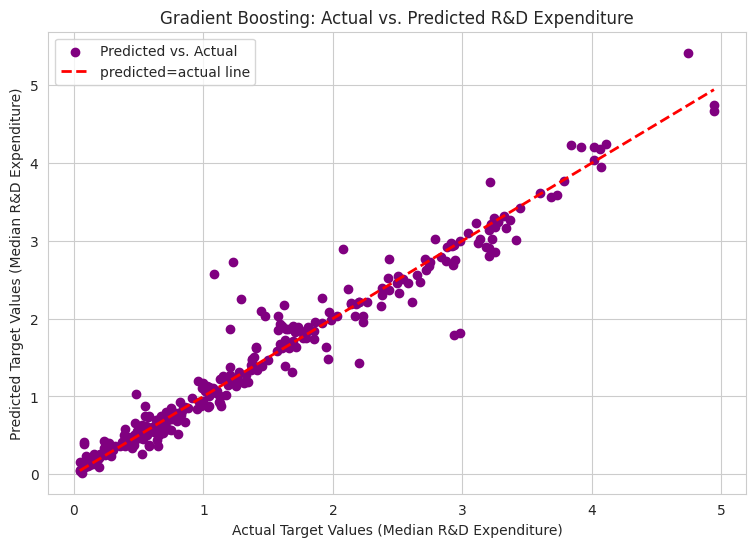

In [46]:
plt.figure(figsize=(9, 6))
plt.scatter(y_test, gb_predictions, alpha=1, color='purple', label='Predicted vs. Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='predicted=actual line')
plt.title('Gradient Boosting: Actual vs. Predicted R&D Expenditure')
plt.xlabel('Actual Target Values (Median R&D Expenditure)')
plt.ylabel('Predicted Target Values (Median R&D Expenditure)')
plt.legend()
plt.show()

**Feature Importance Analysis for Gradient Boosting**

The feature importance score is calculated by determining how much each feature reduces the error across all splits in the trees of the ensemble.

In [47]:
# obtain the feature importances from the trained Gradient Boosting model
importances = gb_model.feature_importances_

# feature names
feature_names = X_train.columns

# series for sorting and plotting
feature_importance_series = pd.Series(importances, index=feature_names)

# sort the features by importance in descending order
sorted_importances = feature_importance_series.sort_values(ascending=False)

print("--- Gradient Boosting Feature Importance Scores ---")
print(sorted_importances.to_markdown(numalign="left", stralign="left", floatfmt=".4f"))

--- Gradient Boosting Feature Importance Scores ---
|                           | 0      |
|:--------------------------|:-------|
| govt_effectiveness        | 0.5508 |
| researchers_per_million   | 0.2194 |
| log_gdp                   | 0.0832 |
| health_spend_pct_gdp      | 0.0540 |
| education_spend_pct_gdp   | 0.0316 |
| region_Asia-Pacific       | 0.0206 |
| life_expectancy           | 0.0201 |
| region_Latin America      | 0.0059 |
| region_Europe             | 0.0052 |
| wui                       | 0.0033 |
| wui_volatility            | 0.0019 |
| region_Middle East        | 0.0017 |
| region_North America      | 0.0007 |
| income_group_Upper-middle | 0.0007 |
| income_group_Lower-middle | 0.0003 |
| income_group_High         | 0.0002 |
| region_Africa             | 0.0002 |


**Visualize Feature Importance**

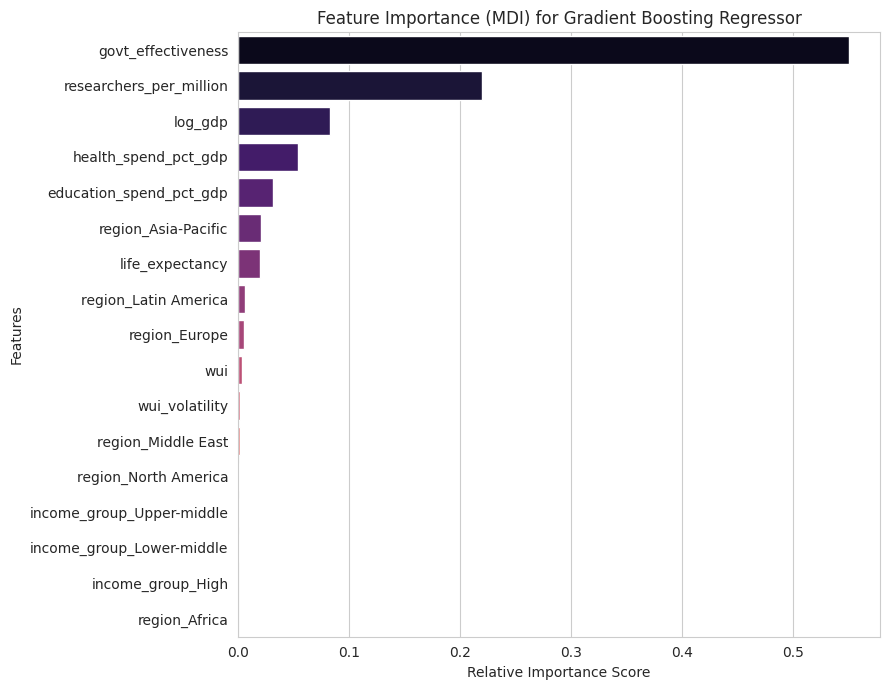

In [48]:
plt.figure(figsize=(9, 7))

# bar plot of the sorted series
# We assign the y variable (feature names) to hue to correctly map the palette.
sns.barplot(x=sorted_importances.values, y=sorted_importances.index,
    hue=sorted_importances.index,  # hue: y : sorted feature names
    palette="magma",
    legend=False)                   # kill the the redundant legend

plt.title('Feature Importance (MDI) for Gradient Boosting Regressor')
plt.xlabel('Relative Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

**Model Performance Comparison**

In [49]:
# all results into a single DataFrame
comparison_df = pd.DataFrame([dt_results_8, dt_results_16, rf_results, gb_results])

# sort by R2 score
comparison_df = comparison_df.sort_values(by='R2', ascending=False).reset_index(drop=True)

print("\n--- Model Comparison Table ---")
print(comparison_df.to_markdown(index=False))


--- Model Comparison Table ---
|       MSE |       R2 | Model                   |
|----------:|---------:|:------------------------|
| 0.0558855 | 0.954762 | Gradient Boosting       |
| 0.0800327 | 0.935215 | Random Forest           |
| 0.0950354 | 0.92307  | Decision Tree_16 levels |
| 0.114267  | 0.907503 | Decision Tree_8 levels  |


**Visualize Comparison**

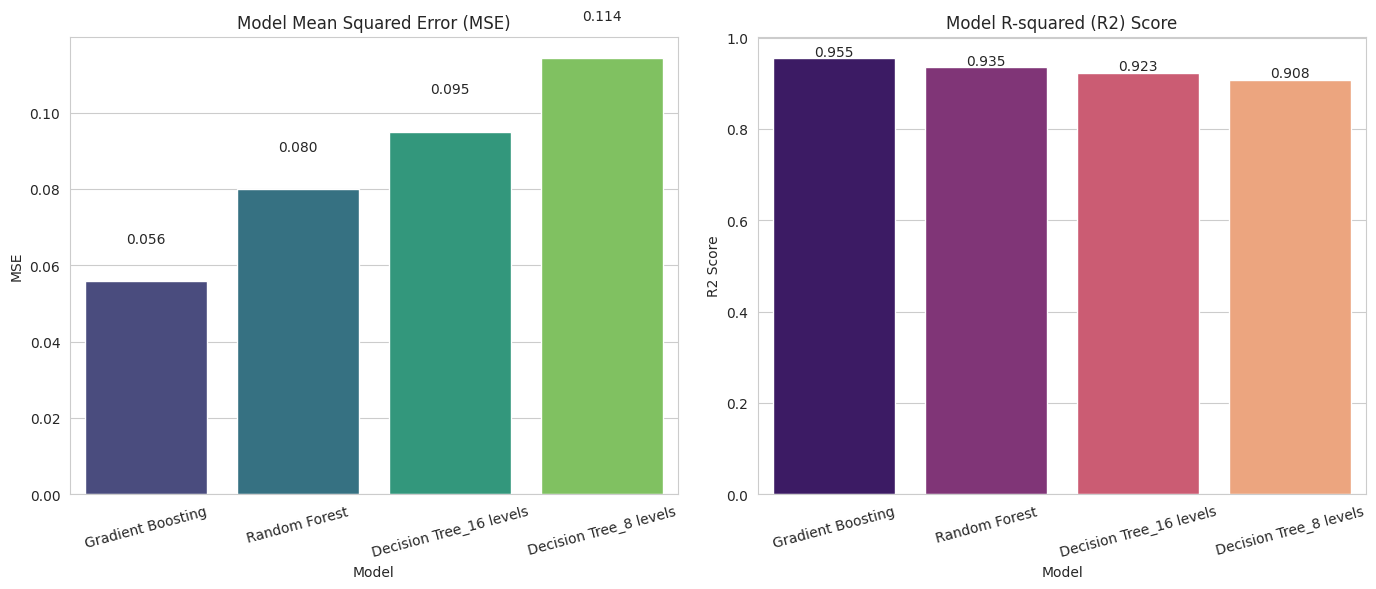

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
models = comparison_df['Model']
mse_scores = comparison_df['MSE']
r2_scores = comparison_df['R2']

# hue: x: 'models' to map palette colors to categories
sns.barplot(ax=axes[0], x=models, y=mse_scores, hue=models, palette="viridis", legend=False)

axes[0].set_title('Model Mean Squared Error (MSE)')
axes[0].set_ylabel('MSE')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(mse_scores):
    axes[0].text(i, v + 0.01, f"{v:.3f}", ha='center')

# hue: x: 'models' to map palette colors to categories
sns.barplot(ax=axes[1], x=models, y=r2_scores, hue=models, palette="magma", legend=False)

axes[1].set_title('Model R-squared (R2) Score')
axes[1].set_ylabel('R2 Score')
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(r2_scores):
    axes[1].text(i, v + 0.005, f"{v:.3f}", ha='center')

plt.tight_layout()
plt.show()

## Support Vector Machines

Define the svr regressor, train it with training subset, and predict rd_spend_pct_gdp with the test subset.
Feature scaling is required as the method relies on comparing distance metrics. For this reason, we use a pipeline to first scale the data, and then do svr.
Parameter C controls the closeness of fit. (More or less equivalent to number of levels in trees.)
Parameter gamma controls the smoothness of the separation hypersurface -- that separates regions. In practice,gamma= scale= 1/(n_features). it is a hyperparameter that defines how far the influence of a single training example reaches. High gamma can lead to overfitting.

Define the model pipeline with scaling, which is crucial for SVM.

In [51]:
# set C=8, gamma=scale; kernel=rbf which is a curved tube
svr_model = Pipeline([ ('scaler', StandardScaler()), ('regressor', SVR(kernel='rbf', C=8, gamma='scale'))])


In [52]:
# Model Training
svr_model.fit(X_train, y_train)

# Prediction
svr_predictions = svr_model.predict(X_test)

# Metrics
svr_mse = mean_squared_error(y_test, svr_predictions)
svr_r2 = r2_score(y_test, svr_predictions)

print("\n--- Support Vector Regressor (SVR) Metrics ---")
print(f"Mean Squared Error (MSE): {svr_mse:.3f}")
print(f"R-squared (R2) Score: {svr_r2:.3f}")


--- Support Vector Regressor (SVR) Metrics ---
Mean Squared Error (MSE): 0.084
R-squared (R2) Score: 0.932


**Visualize actual versus predicted values of rd_spend_pct_gdp**

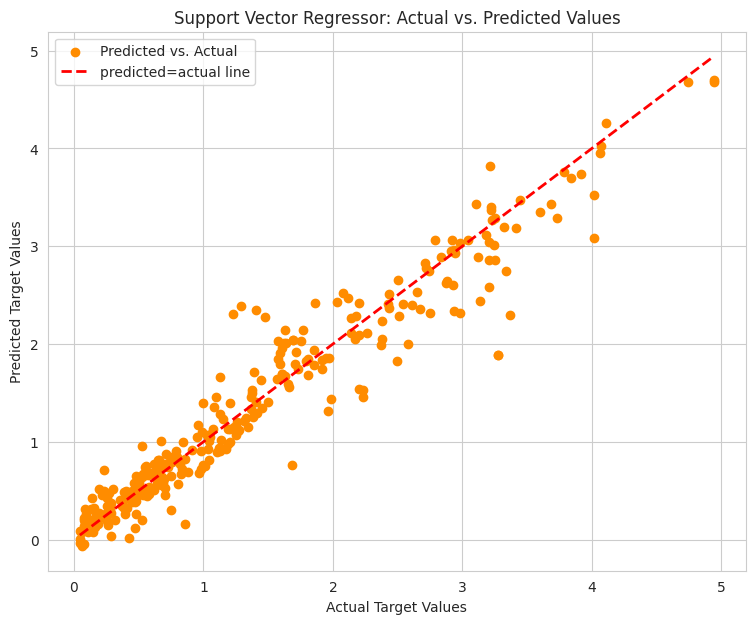

In [58]:
plt.figure(figsize=(9, 7))
plt.scatter(y_test, svr_predictions, alpha=1, color='darkorange', label='Predicted vs. Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='predicted=actual line')
plt.title('Support Vector Regressor: Actual vs. Predicted Values')
plt.xlabel('Actual Target Values')
plt.ylabel('Predicted Target Values')
plt.legend()
plt.show()

## SVR with bagging


--- Bagged Support Vector Regressor (SVR) Metrics ---
Mean Squared Error (MSE): 0.083
R-squared (R2) Score: 0.933


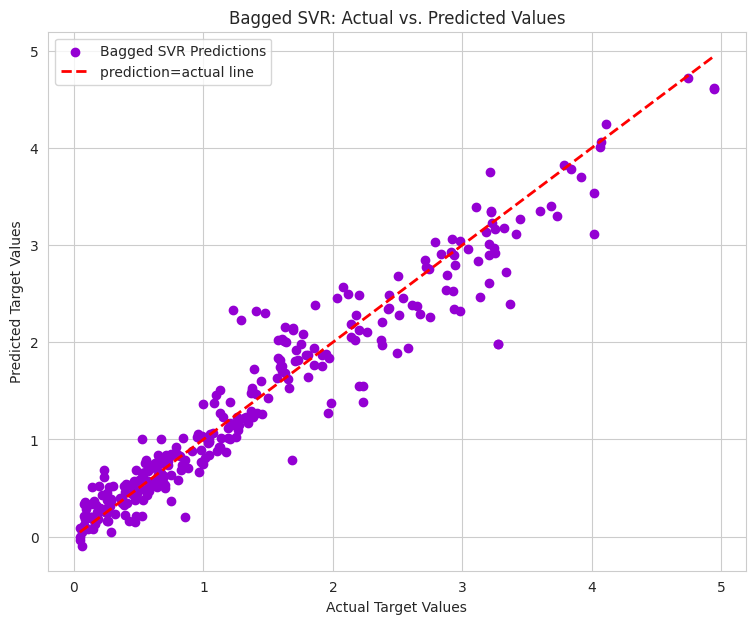

In [54]:
# define the model
# use kernel=rbf, C=8, gamma=scale

base_svr = SVR(kernel='rbf', C=8, gamma='scale')

# bagging regressor
# use n_estimators=8: 8 SVR models
bagged_svr = BaggingRegressor(estimator=base_svr, n_estimators=8, max_samples=1.0, random_state=1,
    n_jobs=-1)  # Use all available cores

# pipeline (Scaling + Bagging)
bagging_pipeline = Pipeline([('scaler', StandardScaler()), ('bagged_svr', bagged_svr)])

# training
bagging_pipeline.fit(X_train, y_train)

# prediction
bagged_svr_predictions = bagging_pipeline.predict(X_test)

# metrics
bagged_svr_mse = mean_squared_error(y_test, bagged_svr_predictions)
bagged_svr_r2 = r2_score(y_test, bagged_svr_predictions)

print("\n--- Bagged Support Vector Regressor (SVR) Metrics ---")
print(f"Mean Squared Error (MSE): {bagged_svr_mse:.3f}")
print(f"R-squared (R2) Score: {bagged_svr_r2:.3f}")

# visualization
plt.figure(figsize=(9, 7))
plt.scatter(y_test, bagged_svr_predictions, alpha=1, color='darkviolet', label='Bagged SVR Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='prediction=actual line')
plt.title('Bagged SVR: Actual vs. Predicted Values')
plt.xlabel('Actual Target Values')
plt.ylabel('Predicted Target Values')
plt.legend()
plt.show()

## SVM boosted with AdaBoost


--- AdaBoost Support Vector Regressor (SVR) Metrics ---
Mean Squared Error (MSE): 0.108
R-squared (R2) Score: 0.912


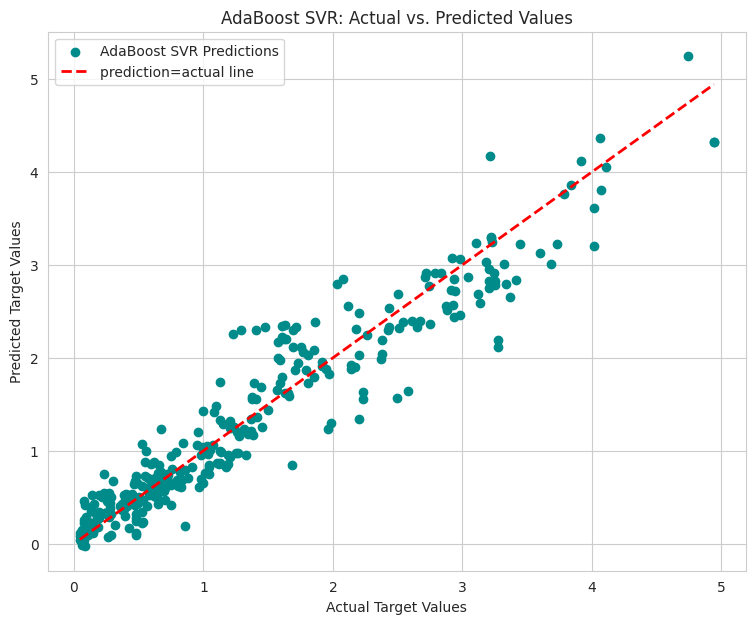

In [55]:
# define the base SVR model. It is sensitive to the C and epsilon parameters in AdaBoost.
# C: regularization parameter: controls smoothness; high C can lead to overfitting
# epsilon: width of insentivity of the tube around the regression line. high epsilon leads to fewer sv. low epsilon to more sv.
# gamma: as before, defines the influence of a single training point, or smoothness of the decision hypercurve.
# it is best to start with a "weak" base model, i.e., low C (ranges 1 to 10), high epsilon (ranges 0.001 to 1)

base_svr = SVR(kernel='rbf', C=1, gamma='scale', epsilon=0.1)

# define the AdaBoost Regressor
# n_estimators=8: Use 8 SVR models sequentially
# learning_rate: Controls the contribution of each SVR
ada_svr = AdaBoostRegressor(estimator=base_svr, n_estimators=8, learning_rate=0.5, random_state=1)

# do the pipeline (Scaling + Boosting)
ada_pipeline = Pipeline([('scaler', StandardScaler()), ('ada_svr', ada_svr)])

# training
ada_pipeline.fit(X_train, y_train)

# prediction
ada_svr_predictions = ada_pipeline.predict(X_test)

# metrics
ada_svr_mse = mean_squared_error(y_test, ada_svr_predictions)
ada_svr_r2 = r2_score(y_test, ada_svr_predictions)

print("\n--- AdaBoost Support Vector Regressor (SVR) Metrics ---")
print(f"Mean Squared Error (MSE): {ada_svr_mse:.3f}")
print(f"R-squared (R2) Score: {ada_svr_r2:.3f}")

# visualization and comparison ---
plt.figure(figsize=(9, 7))
plt.scatter(y_test, ada_svr_predictions, alpha=1, color='darkcyan', label='AdaBoost SVR Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='prediction=actual line')
plt.title('AdaBoost SVR: Actual vs. Predicted Values')
plt.xlabel('Actual Target Values')
plt.ylabel('Predicted Target Values')
plt.legend()
plt.show()

## SVM model comparison

In [56]:
# List of dictionaries with the results
comparison_results = [
    {'Model': 'Single SVR', 'MSE': svr_mse, 'R2': svr_r2},
    {'Model': 'Bagged SVR', 'MSE': bagged_svr_mse, 'R2': bagged_svr_r2},
    {'Model': 'AdaBoost SVR', 'MSE': ada_svr_mse, 'R2': ada_svr_r2}
]

# Put in dataFrame and sort by R2 
comparison_df = pd.DataFrame(comparison_results)
comparison_df = comparison_df.sort_values(by='R2', ascending=False).reset_index(drop=True)

print("\n--- Consolidated SVR Model Comparison Table ---")
# Display the table formatted nicely
print(comparison_df.to_markdown(index=False, floatfmt=".4f"))


--- Consolidated SVR Model Comparison Table ---
| Model        |    MSE |     R2 |
|:-------------|-------:|-------:|
| Bagged SVR   | 0.0830 | 0.9328 |
| Single SVR   | 0.0845 | 0.9316 |
| AdaBoost SVR | 0.1083 | 0.9123 |


**Comparison Barplots**.

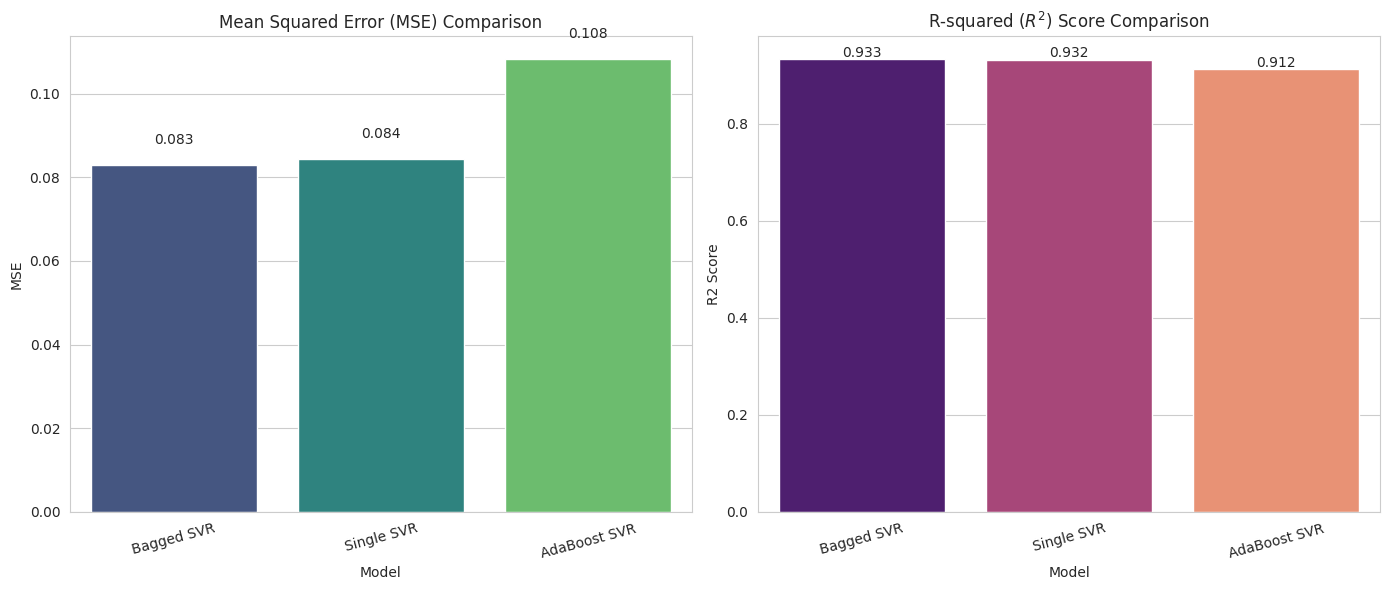

In [62]:
# data to be plotted
models = comparison_df['Model']
mse_scores = comparison_df['MSE']
r2_scores = comparison_df['R2']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: MSE Comparison
sns.barplot(ax=axes[0], x=models, y=mse_scores, hue=models, palette="viridis", legend=False)
axes[0].set_title('Mean Squared Error (MSE) Comparison')
axes[0].set_ylabel('MSE')
axes[0].tick_params(axis='x', rotation=15)
# Add metric values on top of bars
for i, v in enumerate(mse_scores):
    axes[0].text(i, v + 0.005, f"{v:.3f}", ha='center')

# Plot 2: R2 Comparison ---
sns.barplot(ax=axes[1], x=models, y=r2_scores, hue=models, palette="magma", legend=False)
axes[1].set_title('R-squared ($R^2$) Score Comparison')
axes[1].set_ylabel('R2 Score')
axes[1].tick_params(axis='x', rotation=15)
# Add metric values on top of bars
for i, v in enumerate(r2_scores):
    axes[1].text(i, v + 0.005, f"{v:.3f}", ha='center')

plt.tight_layout()
plt.show()

## CONCLUSIONS




Importance of features for predicting R&D expenditure. The evaluated models included as features: GDP/capita, structural factors such as Health and Education investment, lifetime expectancy, world region, income group, uncertainty index, as well as two new features introduced in this final project: Researchers per million and Government effectiveness. The Random Forest model provided a surprising and unforeseen result. The dominating factor is Government effectiveness, followed by Researchers per million, and then GDP/capita and other factors with lower impact. Moreover, the Random Forest model accuracy as measured by R2 exceeds 93%, well above that of the multilinear regression models used for Project 2.

This new result reveals that the economic capacity of countries is not the main determinant of research performance. Rather, it is mainly dependent upon the effectiveness of governments guaranteeing research continuity and a stable legal framework that protects discoveries and encourages investment in research. Then it depends upon the availability of substantial human capital --researchers-- dedicated to scientific or technological advancement. In third place comes country wealth, which is a necessary but not sufficient condition.  This result agrees with the observation that the very top countries by GDP/capita are not the top R&D leaders. Government robustness and consistent policies are key to R&D dominance. Unexplicably, there is a recent tendency among certain wealthy countries to weaken their historically strong financial commitment for fundamental research. As suggested by this model, such government unstable policies can lead to loss of R&D competitiveness in the global stage. This competitiveness loss can be multiplied and accelerated by the loss of researchers who have the ability to move and do their research for other rich countries with more effective governments.

From the point of view of regression methodology all of the methods were very accurate (R2>0.9). In average, decision-tree based methods proved to be slightly more accurate and efficient (less CPU time) than Support Vector Machine methods, for this particular dataset.  Among the three decision tree methods explored,  Gradient Boosting yielded the highest accuracy (largest R2 and lowest MSE) compared to Random Forest and a single decision tree. Among the SVM methods, Bagged SVR appeard slightly more accurate than Adaboot SVR and a single SVR. Two individual samples from the test set were predicted with Random Forest algorithm for low and high R&D investment. The results were satisfactory. We also looked for signs of overfitting with the decision tree method by testing a weaker and a stronger decision tree (8 and 16 level trees). The tree with 16 levels gave a higher R2 than the one with 8 levels. Had there been overfitting, R2 for the 16-level tree would have been lower. Thus we did not find signs of overfitting at the highest level used. 



